### Bias Parameter (B)

#### Definition
The bias B (also called intercept or offset) is a parameter that shifts the entire line vertically. It represents the predicted value when all inputs are zero.

#### Mathematical Interpretation
$$\text{When } X = 0, \quad \hat{y} = W \cdot 0 + B = B$$
B is the y-intercept of the line.

#### Practical Meaning
In house pricing with equation Ŷ = 150X + 50000:

B = $50,000 means there's a "base price" of $50,000 even for a 0-sqft house
This captures fixed costs (land, permits, etc.)
Without B, the line would always pass through the origin (0, 0)

#### Why B Matters

##### Without bias:

Model: Ŷ = W·X (forced through origin)
Problem: Real data rarely fits this constraint
Result: Worse predictions

##### With bias:

Model: Ŷ = W·X + B (can fit anywhere)
Solution: Much more flexible
Result: Better fit to real data

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
#  sample data
x_bias = np.array([0, 500, 1000, 1500, 2000]).reshape(-1,1)
y_bias = np.array([50000, 125000, 200000, 275000, 350000])

In [3]:
# model 1:  without bias (forced through origin)
# this is just demonstration -sklearn always includes bias
w = 150
y_no_bias = w * x_bias #only w *x, no b

In [4]:

# model 2: with bias (proper)
bias = 50000
y_with_bias = w * x_bias + bias 

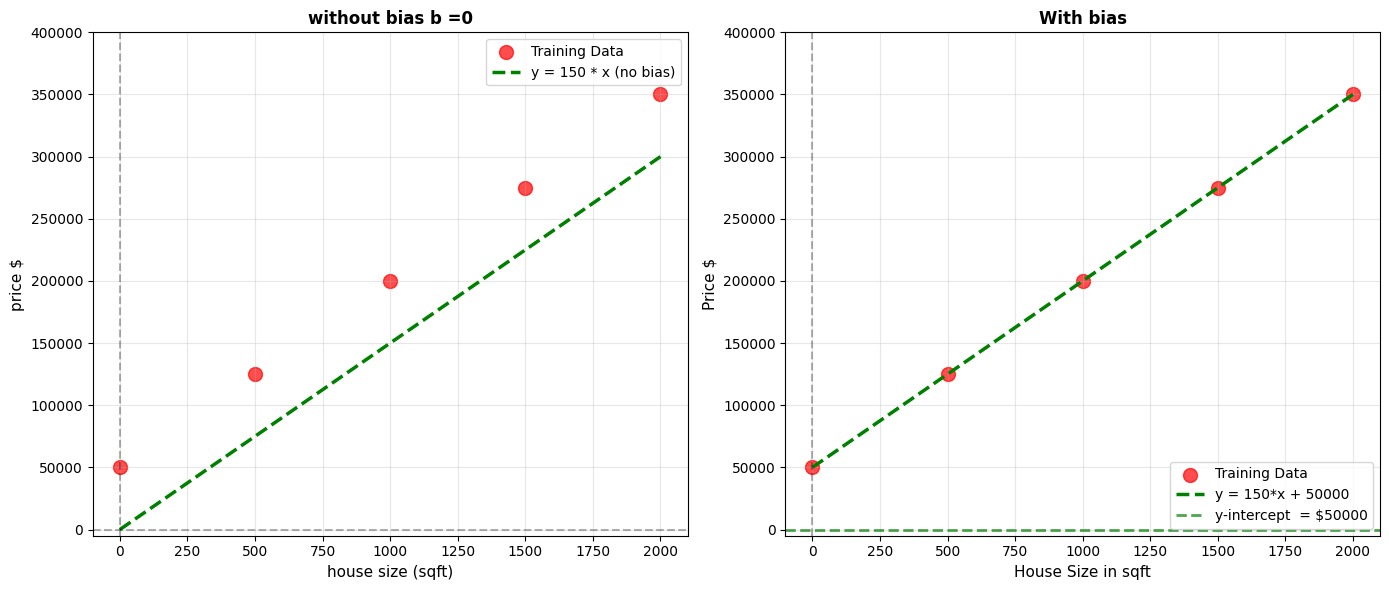

In [5]:
# visualization 
fid, axes = plt.subplots(1,2, figsize=(14,6))

# left plot : without bias
ax = axes[0]
ax.scatter(x_bias, y_bias,marker='o',s = 100, alpha =0.7, label = 'Training Data', c = 'r')
ax.plot(x_bias, y_no_bias, 'g--', linewidth = 2.5, label = f"y = {w} * x (no bias)")
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.axvline(0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel("house size (sqft)",fontsize=11)
ax.set_ylabel("price $",fontsize=11)
ax.set_title('without bias b =0',fontsize=12,weight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([-5000, 400000])
# plt.show()


# right plot : with bias
ax = axes[1]
ax.scatter(x_bias, y_bias, marker='o',s=100, alpha=0.7, label='Training Data', c='r')
ax.plot(x_bias, y_with_bias, 'g--', linewidth=2.5, label=f"y = {w}*x + {bias}")
ax.axhline(0, color = 'g', linestyle ='--', linewidth=2,alpha=0.7, label=f"y-intercept  = ${bias}")
ax.axvline(0, color='k', linestyle= '--', alpha= 0.3)
ax.set_xlabel("House Size in sqft",fontsize=11)
ax.set_ylabel("Price $",fontsize=11)
ax.set_title("With bias",fontsize=12,weight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([-5000, 400000])

plt.tight_layout()
plt.show()


# Console Output:
# Without Bias: Line goes through (0,0) → poor fit
# With Bias: Line captures base price → good fit